# Python Well Log Analysis
## This project will showcase the use of python in reservoir formation evaluation using well log data

### Real well log data was obtained from Kansas field and available at https://kgsimages.blob.core.windows.net/web/web_1/WebDocs/WellLogs/kcc_logs_2025/1056890332.las

In [49]:
# Install neccesary libraries
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Read the well log las file from the webpage of the Kansas geological directory

In [50]:
las = lasio.read('https://kgsimages.blob.core.windows.net/web/web_1/WebDocs/WellLogs/kcc_logs_2025/1056890332.las')
df = las.df()
df.head()

,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI
DEPT,,,,,,,,,,,,,,,,,,
244.0,69.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244.5,71.686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245.0,75.918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245.5,80.436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246.0,76.796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum()

GR      132
CALY    268
CALM    263
CALX    257
SP      130
TENS    131
BS      155
SFL     135
ILD     129
ILM     157
DPHI    123
NPHI    255
PE      125
MINV    137
MNOR    137
DRHO    127
DT      127
SPHI    127
dtype: int64

In [8]:
#Nulls are dropped rather than interpolating such data points to keep the protfolio simple
df = df.dropna()

In [9]:
df.head()

,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI
DEPT,,,,,,,,,,,,,,,,,,
339.5,97.759,8.915,8.112,9.482,33.252,1792.279,7.873,30.719,24.408,25.642,19.270,29.258,2.559,11.374,14.021,0.015,119.483,29.946
340.0,107.505,8.943,8.186,9.527,33.485,1813.362,7.873,28.734,22.865,23.331,18.986,29.006,2.781,11.244,12.614,0.002,121.717,29.946
340.5,115.464,8.938,8.220,9.536,34.530,1825.388,7.873,28.568,21.419,21.320,19.554,29.977,2.746,11.118,12.459,-0.008,124.449,29.947
341.0,119.610,8.929,8.226,9.574,35.577,1829.193,7.873,27.998,20.066,19.482,19.866,29.971,2.701,10.818,12.199,-0.011,128.074,29.947
341.5,127.681,8.920,8.231,9.633,36.481,1832.998,7.873,25.849,18.798,17.801,20.276,29.965,2.655,9.918,11.179,-0.010,130.821,29.947


## Lithology Identification using gamma ray

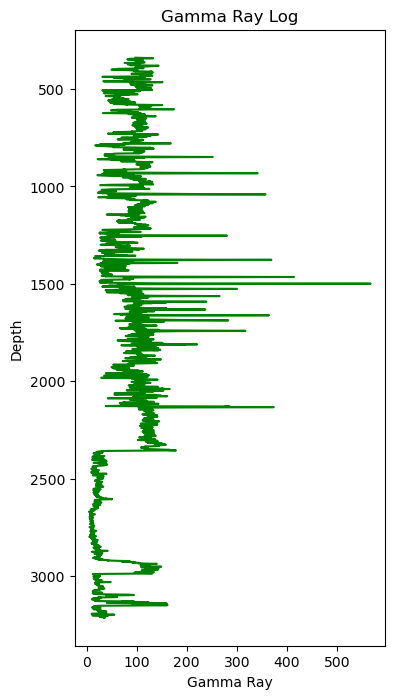

In [10]:
plt.figure(figsize=(4,8))
plt.plot(df['GR'], df.index, color='green')
plt.gca().invert_yaxis()
plt.xlabel("Gamma Ray")
plt.ylabel("Depth")
plt.title("Gamma Ray Log")
plt.show()


## Note 1: 

In [14]:
df.columns

Index(['GR', 'CALY', 'CALM', 'CALX', 'SP', 'TENS', 'BS', 'SFL', 'ILD', 'ILM',
       'DPHI', 'NPHI', 'PE', 'MINV', 'MNOR', 'DRHO', 'DT', 'SPHI'],
      dtype='object')

## Properly identifying reservoir zones using gamma radiation values

In [20]:
df['Reservoir'] = df['GR'] < 75
df.head()


,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI,Reservoir
DEPT,,,,,,,,,,,,,,,,,,,
339.5,97.759,8.915,8.112,9.482,33.252,1792.279,7.873,30.719,24.408,25.642,19.270,29.258,2.559,11.374,14.021,0.015,119.483,29.946,False
340.0,107.505,8.943,8.186,9.527,33.485,1813.362,7.873,28.734,22.865,23.331,18.986,29.006,2.781,11.244,12.614,0.002,121.717,29.946,False
340.5,115.464,8.938,8.220,9.536,34.530,1825.388,7.873,28.568,21.419,21.320,19.554,29.977,2.746,11.118,12.459,-0.008,124.449,29.947,False
341.0,119.610,8.929,8.226,9.574,35.577,1829.193,7.873,27.998,20.066,19.482,19.866,29.971,2.701,10.818,12.199,-0.011,128.074,29.947,False
341.5,127.681,8.920,8.231,9.633,36.481,1832.998,7.873,25.849,18.798,17.801,20.276,29.965,2.655,9.918,11.179,-0.010,130.821,29.947,False


## Identify net pay regions.... sandstone regions with porosity greater than 20%

In [34]:
df['Net Pay'] = (df['GR'] <=75) &  (df['DPHI'] >=20)
df[df['Net Pay'] == True]

,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI,Reservoir,Net Pay
DEPT,,,,,,,,,,,,,,,,,,,,
442.0,73.290,8.740,7.835,8.902,36.072,1985.036,7.873,25.510,14.439,19.285,27.838,29.521,2.527,10.921,13.903,0.012,131.074,30.007,True,True
442.5,61.501,8.739,7.825,8.904,37.543,1986.858,7.873,24.917,15.833,20.149,27.596,26.247,2.202,10.598,13.288,0.017,125.054,30.005,True,True
443.0,55.359,8.738,7.834,8.906,39.014,1990.313,7.873,24.163,17.363,20.346,27.353,25.474,2.044,10.255,13.076,0.014,120.183,30.004,True,True
443.5,54.853,8.737,7.844,8.908,40.509,2005.079,7.873,23.714,18.908,20.544,26.924,26.918,2.149,11.188,12.990,0.006,119.714,30.003,True,True
444.0,63.834,8.736,7.853,8.910,41.477,2019.860,7.873,24.599,19.618,20.745,26.069,27.541,2.262,12.186,13.557,0.003,124.292,30.001,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3212.0,34.257,7.907,7.718,7.856,33.124,2557.258,7.885,23.393,12.845,13.792,20.730,14.420,1.673,11.859,17.039,0.016,77.684,21.302,True,True
3212.5,36.154,7.902,7.719,7.856,31.143,2566.007,7.885,22.588,12.869,13.820,20.928,15.261,1.641,11.963,17.038,0.017,78.065,21.546,True,True
3213.0,35.374,7.896,7.719,7.856,29.153,2566.007,7.885,22.588,12.893,13.847,21.545,15.620,1.651,11.517,17.037,0.018,78.995,22.159,True,True


## Generate a multi-track plot

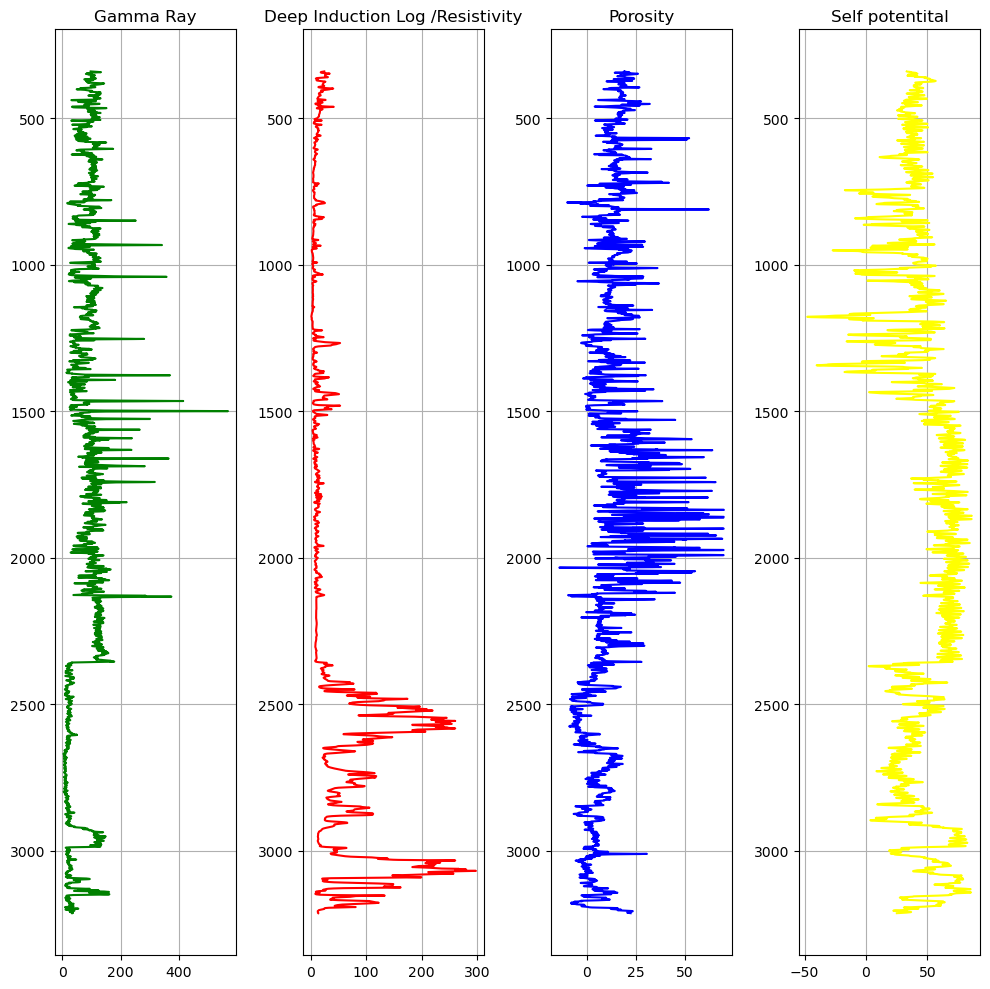

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(10,10))

ax[0].plot(df['GR'], df.index, color='green')
ax[0].set_title("Gamma Ray")

ax[1].plot(df['ILD'], df.index, color='red')
ax[1].set_title("Deep Induction Log /Resistivity")

ax[2].plot(df['DPHI'], df.index, color='blue')
ax[2].set_title("Porosity")

ax[3].plot(df['SP'], df.index, color='yellow')
ax[3].set_title("Self potentital")

for a in ax:
    a.invert_yaxis()
    a.grid()

plt.tight_layout()

plt.savefig("Multi-track Plot.png")

plt.show()


## Interpretation
Low gamma ray intervals correspond to clean sandstones and represent potential reservoir regions of interest.
Gamma ray value of 75 API uit was chosen as the cutoff point.
Porosity values greater or equal to 20%  indicates good reservoir quality.
Net pay zones were identified where both gamma ray and porosity criteria were satisfied.
This region falls within ~2300m to ~3400m. This interval also good shows hih resistivity signatures, as observed on the ILD logs, and is indicative of a good hydrocarbon bearing zone.
